# Analise sequencial de similatidade entre cortes centrais

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
def parse_log(log_data):
    records = []
    current_record = {}

    for line in log_data.strip().split('\n'):
        line = line.strip()
        if line.startswith('ID da Imagem:'):
            current_record['id'] = line.split(': ')[1]
        elif line.startswith('Quantidade de cortes B avaliados:'):
            current_record['cortes'] = int(line.split(': ')[1])
        elif line.startswith('Kernel Window Size:'):
            current_record['windows_size'] = line.split(': ')[1]
        elif line.startswith('Tempo de Leitura Total (A+B):'):
            current_record['tempo_leitura'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Medio Calculo SSIM (por slice):'):
            current_record['tempo_medio_slice'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo de Busca (SSIM loop):'):
            current_record['tempo_busca'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Tempo Total do Processo:'):
            current_record['tempo_total'] = float(line.split(': ')[1].replace(' s', ''))
        elif line.startswith('Melhor Slice (Z):'):
            current_record['melhor_corte'] = int(line.split(': ')[1])
        elif line.startswith('SSIM Maximo Encontrado:'):
            current_record['ssim_maximo'] = float(line.split(': ')[1])
            records.append(current_record)
            current_record = {}
    return pd.DataFrame(records)

In [3]:
file_path = "data/log.txt"
if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        log_content = f.read()
    data_records = parse_log(log_content)
    df = pd.DataFrame(data_records)
else:
    print(f"Arquivo {file_path} não encontrado.")

In [4]:
df.columns

Index(['id', 'windows_size', 'cortes', 'tempo_leitura', 'tempo_medio_slice',
       'tempo_busca', 'tempo_total', 'melhor_corte', 'ssim_maximo'],
      dtype='str')

In [5]:
df.head()

,id,windows_size,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total,melhor_corte,ssim_maximo
0,TRV1P1,3,280,0.782536,0.005276,1.478240,2.261822,198,0.866923
1,TRV1P1,3,280,0.786043,0.005591,1.566349,2.353509,198,0.866923
2,TRV1P1,3,280,0.809144,0.005181,1.450965,2.261208,198,0.866923
3,TRV1P1,3,280,0.855297,0.005111,1.431570,2.288085,198,0.866923
4,TRV1P1,3,280,0.754657,0.005682,1.591265,2.347004,198,0.866923


In [6]:
df[["cortes", "tempo_leitura", "tempo_medio_slice", 
    "tempo_busca", "tempo_total"]].describe()

,cortes,tempo_leitura,tempo_medio_slice,tempo_busca,tempo_total
count,5760.000000,5760.000000,5760.000000,5760.000000,5760.000000
mean,191.034722,0.942780,0.017371,3.323824,4.267557
std,164.288779,0.282420,0.009596,3.739000,3.839745
min,36.000000,0.452191,0.004818,0.187874,0.705875
25%,47.000000,0.711549,0.009978,0.806965,1.678811
50%,115.500000,0.894964,0.016973,1.508314,2.502263
75%,296.250000,1.155213,0.025019,5.186009,5.904651
max,640.000000,2.831564,0.035460,19.995227,21.696141


In [7]:
df['windows_size'].unique()

<StringArray>
['3', '5', '7', '9']
Length: 4, dtype: str

C:\Users\evera\AppData\Local\Temp\ipykernel_14964\4147356242.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


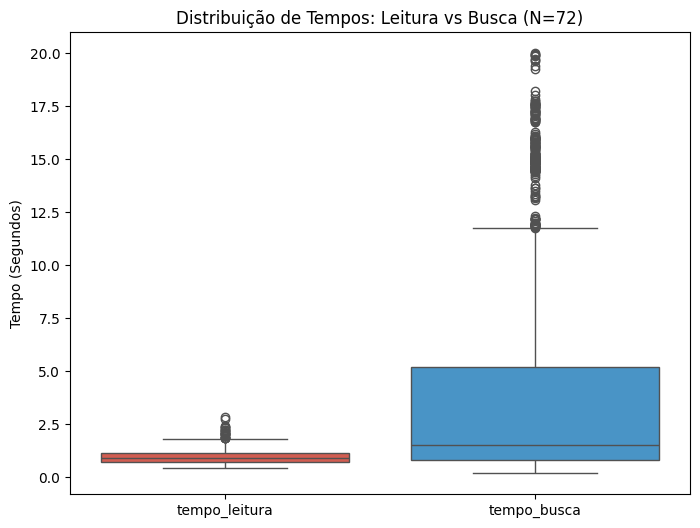

In [8]:
plt.figure(figsize=(8, 6))

df_melted = df[['tempo_leitura', 'tempo_busca']].melt(
    var_name='Etapa do Processamento', 
    value_name='Tempo (s)'
)

sns.boxplot(
    data=df_melted,
    x='Etapa do Processamento',
    y='Tempo (s)',
    palette=['#e74c3c', '#3498db']
)

plt.title('Distribuição de Tempos: Leitura vs Busca (N=72)')
plt.ylabel('Tempo (Segundos)')
plt.xlabel('')
plt.show()

C:\Users\evera\AppData\Local\Temp\ipykernel_14964\1758808000.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


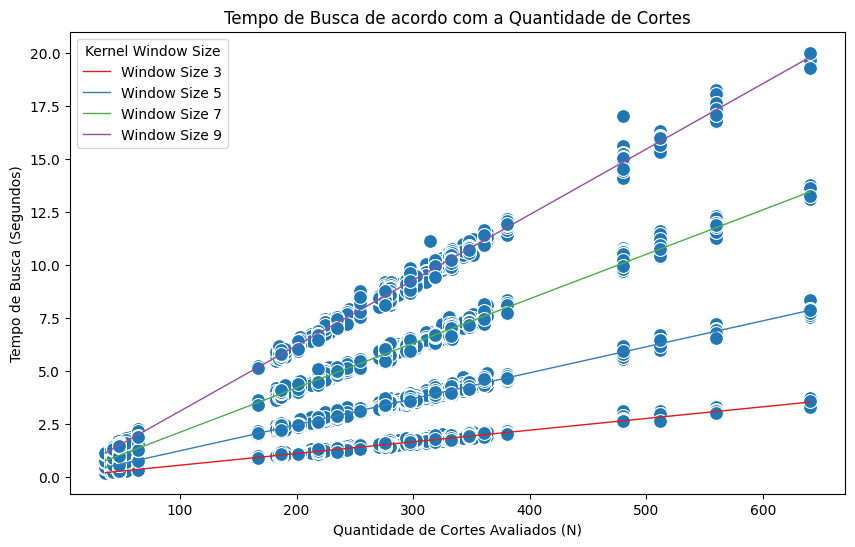

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='cortes', 
    y='tempo_busca', 
    s=100, # tamanho das bolinhas
    palette='deep',
    legend=False
)

windows_sizes = df['windows_size'].unique()
colors = sns.color_palette('Set1', n_colors=len(windows_sizes))
for i, ws in enumerate(windows_sizes):
    subset = df[df['windows_size'] == ws]
    sns.regplot(
        data=subset,
        x='cortes',
        y='tempo_busca',
        scatter=False,
        color=colors[i],
        line_kws={'linewidth': 1},
        label=f'Window Size {ws}'
    )
plt.legend(title='Kernel Window Size')
plt.title('Tempo de Busca de acordo com a Quantidade de Cortes')
plt.ylabel('Tempo de Busca (Segundos)')
plt.xlabel('Quantidade de Cortes Avaliados (N)')
plt.show()

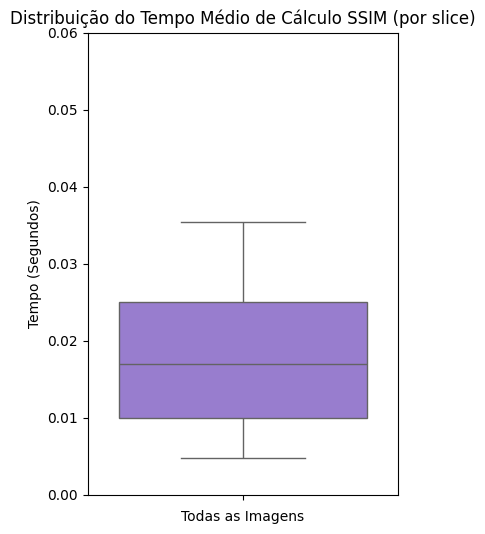

In [10]:
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df,
    y='tempo_medio_slice', 
    color='mediumpurple'
)

plt.title('Distribuição do Tempo Médio de Cálculo SSIM (por slice)')
plt.ylabel('Tempo (Segundos)')
plt.xlabel('Todas as Imagens')
plt.ylim(0.00, 0.06)
plt.show()
